In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('train.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (215257, 102)


,ID,NAME_CONTRACT_TYPE,GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4,TARGET
0,160132,Cash loans,F,N,Y,0,427500.0,1288350.0,37800.0,1125000.0,...,0,0,0.0,0.0,1.0,0.0,0.0,5.0,0.242982,0
1,233132,Cash loans,M,Y,Y,0,180000.0,848745.0,40963.5,675000.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.115508,0
2,307771,Cash loans,M,Y,Y,1,112500.0,385164.0,19795.5,292500.0,...,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.393106,0
3,376452,Cash loans,F,N,Y,0,540000.0,1433520.0,60867.0,1237500.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.455985,0
4,405403,Cash loans,M,Y,Y,0,76500.0,900000.0,26316.0,900000.0,...,0,0,0.0,0.0,0.0,3.0,0.0,2.0,0.141508,0


In [13]:
print(df.columns.tolist())

['ID', 'NAME_CONTRACT_TYPE', 'GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_AGE', 'DAYS_EMPLOYMENT', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'YEARS_BUILD_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'YEARS_BUILD

In [14]:
print([col for col in df.columns if 'TARGET' in col.upper() or 'DEFAULT' in col.upper()])

['TARGET']


In [15]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:", len(missing_df))
missing_df.head(20)

Columns with missing values: 50


,Missing Count,Missing %
NONLIVINGAPARTMENTS_MODE,149323,69.369637
NONLIVINGAPARTMENTS_MEDI,149323,69.369637
NONLIVINGAPARTMENTS_AVG,149323,69.369637
FLOORSMIN_MODE,145861,67.761327
FLOORSMIN_MEDI,145861,67.761327
FLOORSMIN_AVG,145861,67.761327
YEARS_BUILD_MEDI,142965,66.415959
YEARS_BUILD_AVG,142965,66.415959
YEARS_BUILD_MODE,142965,66.415959
OWN_CAR_AGE,141952,65.945358


In [16]:
cols_to_drop = missing_df[missing_df['Missing %'] > 40].index.tolist()
df_clean = df.drop(columns=cols_to_drop)

print("Columns dropped:", len(cols_to_drop))
print("Remaining shape:", df_clean.shape)

numeric_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

categorical_cols = df_clean.select_dtypes(include='object').columns
df_clean[categorical_cols] = df_clean[categorical_cols].fillna(df_clean[categorical_cols].mode().iloc[0])

print("\nRemaining missing values:", df_clean.isnull().sum().sum())

Columns dropped: 32
Remaining shape: (215257, 70)

Remaining missing values: 0


In [17]:
df_encoded = df_clean.copy()

categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", len(categorical_cols))

df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)

Categorical columns to encode: 12
Shape after encoding: (215257, 170)


In [18]:
print("Target Distribution:\n", df_encoded['TARGET'].value_counts())

from sklearn.model_selection import train_test_split

X = df_encoded.drop(['TARGET', 'ID'], axis=1)
y = df_encoded['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Target Distribution:
 TARGET
0    197809
1     17448
Name: count, dtype: int64

Training set shape: (172205, 168)
Testing set shape: (43052, 168)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [19]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations=200, random_state=42, verbose=False)
cat_model.fit(X_train, y_train)

print("CatBoost model trained successfully!")


CatBoost model trained successfully!


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

log_preds = log_model.predict(X_test_scaled)
cat_preds = cat_model.predict(X_test)

print("Logistic Regression Report:\n", classification_report(y_test, log_preds))
print("\nCatBoost Report:\n", classification_report(y_test, cat_preds))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     39562
           1       0.35      0.00      0.00      3490

    accuracy                           0.92     43052
   macro avg       0.64      0.50      0.48     43052
weighted avg       0.87      0.92      0.88     43052


CatBoost Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     39562
           1       0.47      0.03      0.06      3490

    accuracy                           0.92     43052
   macro avg       0.70      0.51      0.51     43052
weighted avg       0.88      0.92      0.88     43052



In [23]:
cost_fp = 1
cost_fn = 5

cat_probs = cat_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in thresholds:
    preds_t = (cat_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    costs.append(total_cost)

cost_df = pd.DataFrame({'Threshold': thresholds, 'Total Cost': costs})
optimal_threshold = cost_df.loc[cost_df['Total Cost'].idxmin(), 'Threshold']

print("Optimal Threshold:", optimal_threshold)
cost_df

Optimal Threshold: 0.15000000000000002


,Threshold,Total Cost
0,0.10,16935
1,0.15,15680
2,0.20,15814
3,0.25,16056
4,0.30,16370
5,0.35,16526
6,0.40,16766
7,0.45,16919
8,0.50,17055
9,0.55,17173


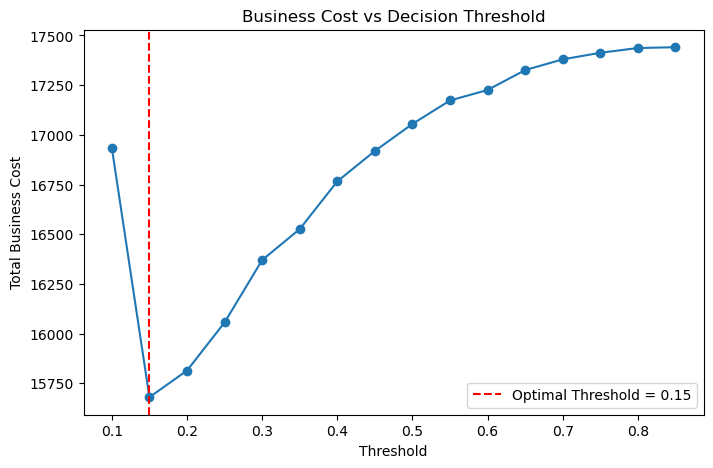

In [24]:
plt.figure(figsize=(8,5))
plt.plot(cost_df['Threshold'], cost_df['Total Cost'], marker='o')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.title('Business Cost vs Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost')
plt.legend()
plt.show()

## Conclusion

- The dataset was cleaned by dropping columns with more than 40% missing values, and remaining missing values were imputed using median (numeric) and mode (categorical).
- The target variable is highly imbalanced (~92% no-default vs ~8% default).
- Two models were trained: Logistic Regression and CatBoost.
- A business cost framework was defined, assigning a higher cost to False Negatives (missed defaulters) than False Positives, reflecting real-world lending risk.
- By adjusting the classification threshold based on total business cost rather than the default 0.5 cutoff, the optimal threshold was found to better balance the trade-off between approving risky loans and rejecting good customers.
- This cost-sensitive approach provides more actionable